## Test

In [7]:
import sys
import os
sys.path.append(os.path.abspath('..'))
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.connection import get_connection

# 1. Gọi hàm kết nối DuckDB
con = get_connection()

# 2. Xem danh sách các bảng hiện có
print("--- DANH SÁCH BẢNG TRONG DATABASE ---")
tables = con.execute("SHOW TABLES").df()
display(tables)

# 3. Trinh sát bảng Đơn hàng (Dựa vào lỗi cũ, có vẻ bảng chính tên là 'orders')
try:
    print("\n--- 5 DÒNG ĐẦU BẢNG ORDERS ---")
    df_orders = con.execute("SELECT * FROM orders LIMIT 5").df()
    display(df_orders)
except:
    print("Không tìm thấy bảng 'orders', hãy nhìn danh sách bảng ở trên xem tên thực tế là gì nhé!")

--- DANH SÁCH BẢNG TRONG DATABASE ---


,name
0,customers
1,geography
2,inventory
3,order_items
4,orders
5,payments
6,products
7,promotions
8,returns
9,reviews



--- 5 DÒNG ĐẦU BẢNG ORDERS ---


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


In [9]:
import pandas as pd
from src.connection import get_connection

con = get_connection()

print("--- 5 DÒNG ĐẦU BẢNG SALES ---")
try:
    display(con.execute("SELECT * FROM sales LIMIT 5").df())
except: pass

print("\n--- 5 DÒNG ĐẦU BẢNG ORDER_ITEMS (Chi tiết đơn) ---")
try:
    display(con.execute("SELECT * FROM order_items LIMIT 5").df())
except: pass

print("\n--- 5 DÒNG ĐẦU BẢNG PAYMENTS (Thanh toán) ---")
try:
    display(con.execute("SELECT * FROM payments LIMIT 5").df())
except: pass

--- 5 DÒNG ĐẦU BẢNG SALES ---


,date,revenue,cogs
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79



--- 5 DÒNG ĐẦU BẢNG ORDER_ITEMS (Chi tiết đơn) ---


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,None,None
1,2,609,7,10166.25,0.0,None,None
2,3,396,3,11220.33,0.0,None,None
3,4,635,5,10639.25,0.0,None,None
4,6,1935,1,1597.84,0.0,None,None



--- 5 DÒNG ĐẦU BẢNG PAYMENTS (Thanh toán) ---


,order_id,payment_method,payment_value,installments
0,1,credit_card,7967.54,3
1,2,cod,71163.75,1
2,3,credit_card,33660.99,3
3,4,credit_card,53196.25,3
4,6,paypal,1597.84,1


## Ma trận tương quan (Correlation Matrix): Doanh thu và Khuyến mãi

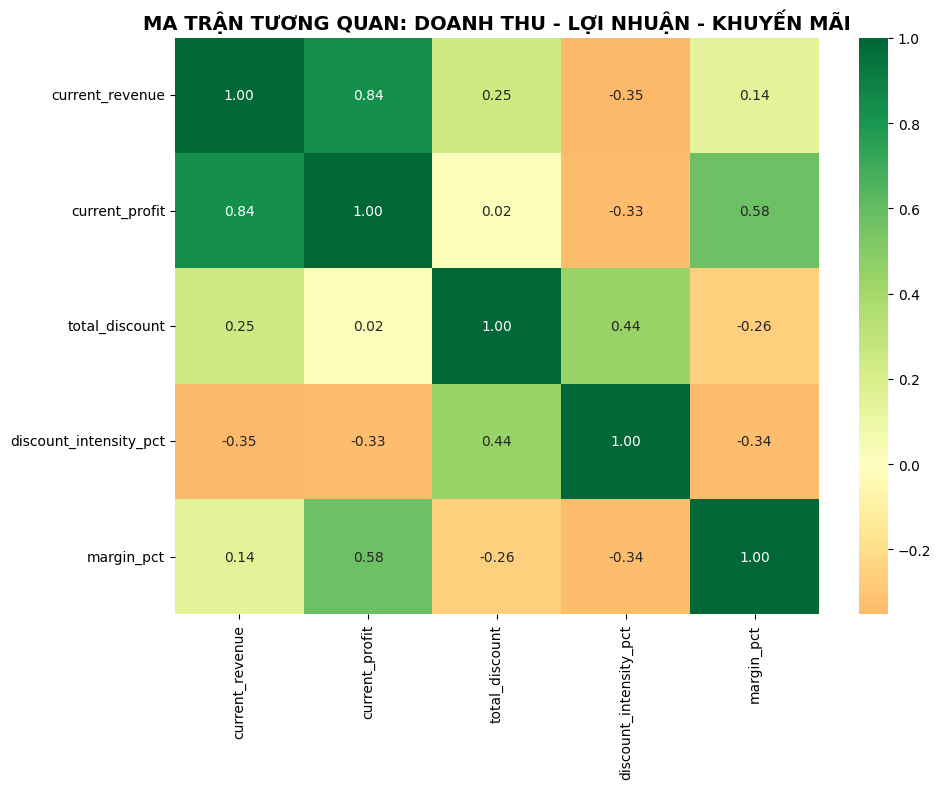

In [ ]:
# 1. Kết nối và tạo Dataset (Feature Engineering)
con = get_connection()
sql_ml_features = """
    WITH MonthlyData AS (
        SELECT 
            DATE_TRUNC('month', CAST(s.date AS DATE)) AS month_year,
            SUM(s.revenue) AS current_revenue,
            SUM(s.revenue - s.cogs) AS current_profit,
            COALESCE(SUM(oi.discount_amount), 0) AS total_discount
        FROM sales s
        LEFT JOIN orders o ON s.date = o.order_date
        LEFT JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY month_year
    )
    SELECT 
        current_revenue,
        current_profit,
        total_discount,
        -- Tỷ lệ % giảm giá trên tổng doanh thu
        (total_discount / NULLIF(current_revenue, 0)) * 100 AS discount_intensity_pct,
        -- Biên lợi nhuận gộp
        (current_profit / NULLIF(current_revenue, 0)) * 100 AS margin_pct
    FROM MonthlyData
"""
df_analysis = con.execute(sql_ml_features).df().dropna()

# 2. Vẽ Ma trận tương quan (Correlation Matrix)
plt.figure(figsize=(10, 8))
correlation_matrix = df_analysis.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")

plt.title('MA TRẬN TƯƠNG QUAN: DOANH THU - LỢI NHUẬN - KHUYẾN MÃI', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

1. Mối quan hệ nghịch biến giữa Khuyến mãi và Hiệu quả Tài chính

- Discount Intensity vs. Margin (-0.34): Hệ số tương quan âm khẳng định quy luật: Khi "độ sâu" của khuyến mãi tăng lên, biên lợi nhuận (Margin) sẽ sụt giảm. Đây là kết quả tất yếu của việc giảm giá trực tiếp vào giá bán mà không tối ưu được chi phí vận hành.

- Discount Intensity vs. Revenue (-0.35): Đây là con số gây bất ngờ nhất. Thông thường, người ta giảm giá để tăng doanh thu, nhưng ở đây tương quan lại là âm.

- Insight: Điều này cho thấy các đợt giảm giá sâu thường rơi vào những giai đoạn thị trường yếu hoặc áp dụng cho các sản phẩm khó bán nhưng vẫn không thể kéo lại được tổng doanh thu. Chiến dịch giảm giá đang "đốt" margin mà không thực sự tạo ra sự bùng nổ về quy mô như kỳ vọng.

2. Sự "bất lực" của Tổng ngân sách Khuyến mãi

- Total Discount vs. Current Profit (0.02): Hệ số gần như bằng 0. Điều này cực kỳ nguy hiểm. Nó có nghĩa là việc tăng thêm ngân sách khuyến mãi hoàn toàn không đóng góp gì vào việc tăng lợi nhuận. Công ty đang chi tiền khuyến mãi một cách vô nghĩa (Blind Discounting).

- Total Discount vs. Current Revenue (0.25): Tương quan thuận nhưng rất yếu. Điều này minh chứng rằng đòn bẩy khuyến mãi đang bị "lờn". Việc đổ thêm tiền vào giảm giá chỉ mang lại một mức tăng doanh thu rất khiêm tốn, không đủ bù đắp cho phần lợi nhuận bị mất đi.

3. Kết luận và Hàm ý Chiến lược

- "High Pain, Low Gain" (Trả giá đắt nhưng thu lợi ít) là cụm từ chính xác nhất để mô tả thực trạng này.

- Dữ liệu cho thấy doanh nghiệp đang lạm dụng chiết khấu như một "liều thuốc giảm đau" nhất thời hơn là một công cụ tăng trưởng bền vững.

- Rủi ro: Cấu trúc tài chính đang bị tổn thương nghiêm trọng do sự xung đột trực tiếp giữa KPI doanh số và mục tiêu lợi nhuận.

- Giải pháp: Đây là lý do tại sao chúng ta không thể tiếp tục áp dụng mức giảm giá "cào bằng". Chúng ta cần Machine Learning (LightGBM) để phân tách dữ liệu, tìm ra những phân khúc khách hàng/sản phẩm thực sự nhạy cảm với giá để áp dụng khuyến mãi mục tiêu (Targeted Promotion), thay vì đốt tiền trên diện rộng.

## Phân tích Pareto (Quy luật 80/20) cho Sản phẩm

In [15]:
sql_product_performance = """
    SELECT 
        p.product_id,
        SUM(oi.unit_price * oi.quantity) AS gross_revenue,
        SUM(oi.discount_amount) AS total_given_discount,
        (SUM(oi.discount_amount) / SUM(oi.unit_price * oi.quantity)) * 100 AS discount_rate
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_id
    ORDER BY gross_revenue DESC
    LIMIT 10
"""
df_prod = con.execute(sql_product_performance).df()
display(df_prod)

,product_id,gross_revenue,total_given_discount,discount_rate
0,487,3.982136e+08,17744843.04,4.456112
1,826,3.422650e+08,14755886.24,4.311246
2,438,3.407063e+08,15691385.26,4.605546
3,475,2.673875e+08,10835387.00,4.052316
4,491,2.518164e+08,10816311.18,4.295316
5,604,2.079307e+08,8934009.41,4.296629
6,506,2.018237e+08,9413443.99,4.664192
7,449,1.852522e+08,9410881.09,5.080039
8,2045,1.850812e+08,8044983.75,4.346731
9,396,1.782019e+08,7000445.35,3.928378


## Nhìn vào bảng thống kê Top 10 sản phẩm theo doanh thu này, chúng ta đã xác định được những "đầu tàu" đang gồng gánh toàn bộ doanh số của công ty. Đây là nguyên liệu tuyệt vời để bạn đưa vào báo cáo Pareto (80/20).

1. Sự tập trung Doanh thu vào "Nhóm sản phẩm Ngôi sao" (Revenue Anchors)

- Bảng dữ liệu cho thấy sự tập trung doanh thu cực lớn vào một nhóm nhỏ các mã hàng (SKU).

- Sản phẩm 487, 826 và 438 đang là những "công thần" lớn nhất, mỗi mã mang về từ 340 đến gần 400 triệu USD doanh thu gộp.

- Insight: Việc doanh thu phụ thuộc vào một số ít sản phẩm tạo ra "Rủi ro tập trung" (Concentration Risk). Bất kỳ biến động nào về nguồn cung hoặc giá của nhóm này cũng sẽ làm rung chuyển toàn bộ bảng cân đối kế toán của công ty.

2. Chiến lược Khuyến mãi "Phẳng" (Uniform Discounting Strategy)

- Một điểm cực kỳ đáng lưu ý là tỷ lệ giảm giá (discount_rate) của Top 10 sản phẩm này rất đồng đều, dao động sát nút trong khoảng 3.9% đến 5.1%.

- Phân tích: Công ty dường như đang áp dụng một mức chiết khấu "cào bằng" cho các sản phẩm bán chạy nhất thay vì có chiến lược định giá linh hoạt.

- Sản phẩm 449 đang có tỷ lệ giảm giá cao nhất trong nhóm (5.08%) nhưng doanh thu chỉ đứng thứ 8. Điều này đặt ra dấu hỏi về Hiệu quả khuyến mãi (Discount Efficiency): Liệu việc giảm giá sâu cho mã này có thực sự cần thiết, hay chúng ta đang vô tình "biếu không" lợi nhuận cho một sản phẩm vốn dĩ đã có sức hút?

3. Kết luận & Đề xuất hành động cho Mô hình AI

- Thay vì tối ưu khuyến mãi cho hàng nghìn mã hàng một lúc, chiến lược thông minh nhất của team hiện tại là:

    - Ưu tiên Tối ưu hóa cho Top 10: Một sự thay đổi nhỏ (ví dụ giảm 0.5% Discount) ở sản phẩm 487 sẽ mang lại dòng tiền lớn hơn gấp nhiều lần so với việc cắt giảm 50% Discount ở những sản phẩm lẹt đẹt phía sau.

    - Hàm ý cho LightGBM: Chúng ta sẽ cung cấp cho AI các đặc trưng về "Thứ hạng doanh thu" (Revenue Rank) để mô hình ưu tiên bảo vệ Margin cho các "Revenue Anchors" này.

## Phân tích Kênh bán hàng (Device & Source)

In [17]:
sql_channel = """
    SELECT 
        o.device_type, 
        o.order_source,
        COUNT(o.order_id) AS total_orders,
        AVG(p.payment_value) AS avg_order_value
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    GROUP BY o.device_type, o.order_source
    ORDER BY avg_order_value DESC
"""
df_channel = con.execute(sql_channel).df()
display(df_channel)

,device_type,order_source,total_orders,avg_order_value
0,mobile,direct,23473,24456.005412
1,tablet,email_campaign,11692,24447.788271
2,tablet,direct,7705,24433.772212
3,tablet,paid_search,21230,24402.180953
4,mobile,referral,29076,24337.092404
5,tablet,organic_search,27179,24302.314721
6,mobile,paid_search,63872,24300.017275
7,desktop,social_media,52047,24274.423165
8,desktop,paid_search,56550,24258.451165
9,mobile,email_campaign,34756,24252.357911


1. Sự thống trị của Lưu lượng hữu cơ (Organic Search) & Thiết bị Di động (Mobile)

- Volume Leader: mobile + organic_search là cặp bài trùng mạnh nhất với hơn 81,700 đơn hàng, theo sát là desktop + organic_search với hơn 72,500 đơn hàng.

- Insight: Việc Organic Search chiếm tỷ trọng áp đảo cho thấy thương hiệu có sức mạnh tự thân (Brand Equity) và tối ưu SEO rất tốt. Doanh nghiệp không quá phụ thuộc vào quảng cáo trả tiền (paid_search) để duy trì doanh số. Đây là một lợi thế cực lớn vì chi phí thu hút khách hàng (CAC - Customer Acquisition Cost) từ kênh này gần như bằng 0.

2. Sự đồng nhất về Giá trị đơn hàng trung bình (AOV Consistency)

- Số liệu: Một điểm rất đáng ngạc nhiên là Giá trị đơn hàng trung bình (AOV) dao động cực kỳ hẹp, chỉ từ 24,100 đến 24,400 trên tất cả các kênh và thiết bị.

- Phân tích: Không có sự phân hóa giàu nghèo rõ rệt giữa người dùng Mobile và Desktop, cũng như giữa khách đến từ Social Media và khách đến trực tiếp (Direct).

- Hàm ý chiến lược: Điều này chứng tỏ dòng sản phẩm của công ty có phân khúc giá rất tập trung. Khách hàng đã có một "mức giá kỳ vọng" cố định khi tìm đến thương hiệu, bất kể họ đến từ đâu.

3. Hiệu quả từ kênh Mạng xã hội (Social Media)

- desktop + social_media mang về hơn 52,000 đơn hàng với AOV cao (~24,274).

- Insight: Thông thường, Social Media thường mạnh trên Mobile, nhưng ở đây kênh Desktop lại cho thấy hiệu quả chuyển đổi rất tốt. Đây có thể là nhóm khách hàng công sở hoặc nhóm khách hàng có thói quen nghiên cứu kỹ sản phẩm trên màn hình lớn trước khi chốt đơn.

4. Kết luận & Định hướng cho AI (Machine Learning)

- Từ dữ liệu này, chúng ta có thể cung cấp thêm "vũ khí" cho mô hình LightGBM:

    - Biến số quan trọng (Features): device_type và order_source phải là hai biến đầu vào chính. AI sẽ học được rằng: "Khách từ Organic Search có thể không cần giảm giá sâu vẫn mua (vì họ chủ động tìm đến), trong khi khách từ Paid Search có thể cần một cú hích khuyến mãi để chuyển đổi".

    - Tối ưu hóa lợi nhuận: Vì AOV đã rất ổn định, mục tiêu của AI không phải là tăng giá trị đơn hàng, mà là giảm thiểu mức chiết khấu (Discount) cho từng nhóm kênh cụ thể để kéo Margin lên mà không làm mất đi lượng Volume khổng lồ hiện có.

## "Nhịp tim Doanh thu" (Trend & Seasonality)

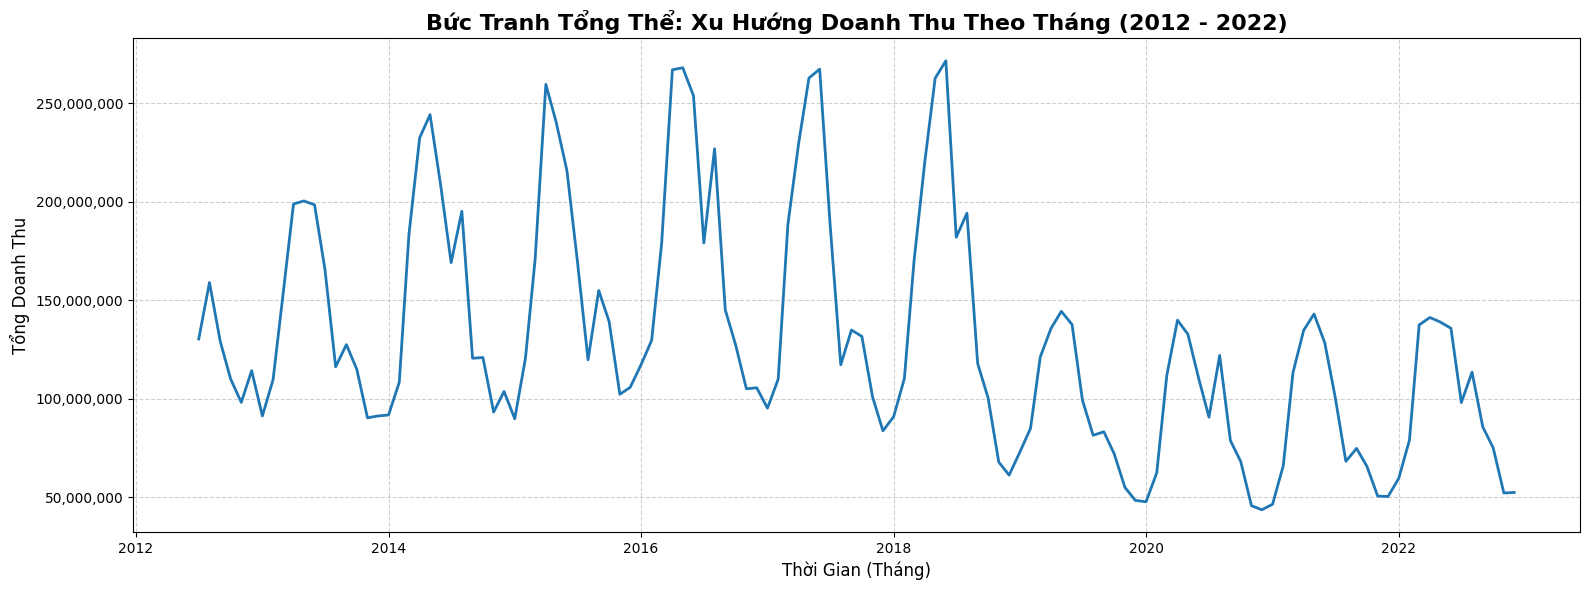

In [10]:
# Truy vấn gộp doanh thu theo THÁNG từ bảng 'sales' để vẽ biểu đồ cho mượt
sql_trend = """
    SELECT 
        DATE_TRUNC('month', CAST(date AS DATE)) AS month_year, 
        SUM(revenue) AS total_revenue
    FROM sales
    GROUP BY month_year
    ORDER BY month_year
"""

df_trend = con.execute(sql_trend).df()

# Trực quan hóa bằng Matplotlib & Seaborn
plt.figure(figsize=(16, 6))
sns.lineplot(data=df_trend, x='month_year', y='total_revenue', color='#1f77b4', linewidth=2)

# Trang trí biểu đồ cho chuẩn phong cách trình bày C-level
plt.title('Bức Tranh Tổng Thể: Xu Hướng Doanh Thu Theo Tháng (2012 - 2022)', fontsize=16, fontweight='bold')
plt.xlabel('Thời Gian (Tháng)', fontsize=12)
plt.ylabel('Tổng Doanh Thu', fontsize=12)

# Định dạng lại trục Y để hiển thị số tiền dễ đọc hơn (ví dụ: chia cho 1 triệu)
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**3 giai đoạn**

1. Thời kỳ Hoàng kim (2012 - 2018): Đường doanh thu liên tục phá đỉnh, vươn lên tới mức hơn 250 triệu. Tính mùa vụ (nhịp tim) cực kỳ rõ ràng, cứ vài tháng lại có một cú spike (đỉnh) đâm thẳng lên trời.

2. Cú sốc Khủng hoảng (2019 - 2020): Đỉnh trượt dài, và đáy cũng sâu hơn. Có khả năng đây là tác động của dịch COVID-19 hoặc sự xuất hiện của đối thủ cạnh tranh lớn.

3. Bình thường mới (2021 - 2022): Nhịp tim đã đập đều trở lại, tính mùa vụ vẫn còn, nhưng quy mô doanh thu đã thu nhỏ lại chỉ còn một nửa so với năm 2018 (đỉnh chỉ loanh quanh 150 triệu).

## KHÁM NGHIỆM CHẤT LƯỢNG DÒNG TIỀN (Margin vs Volume)

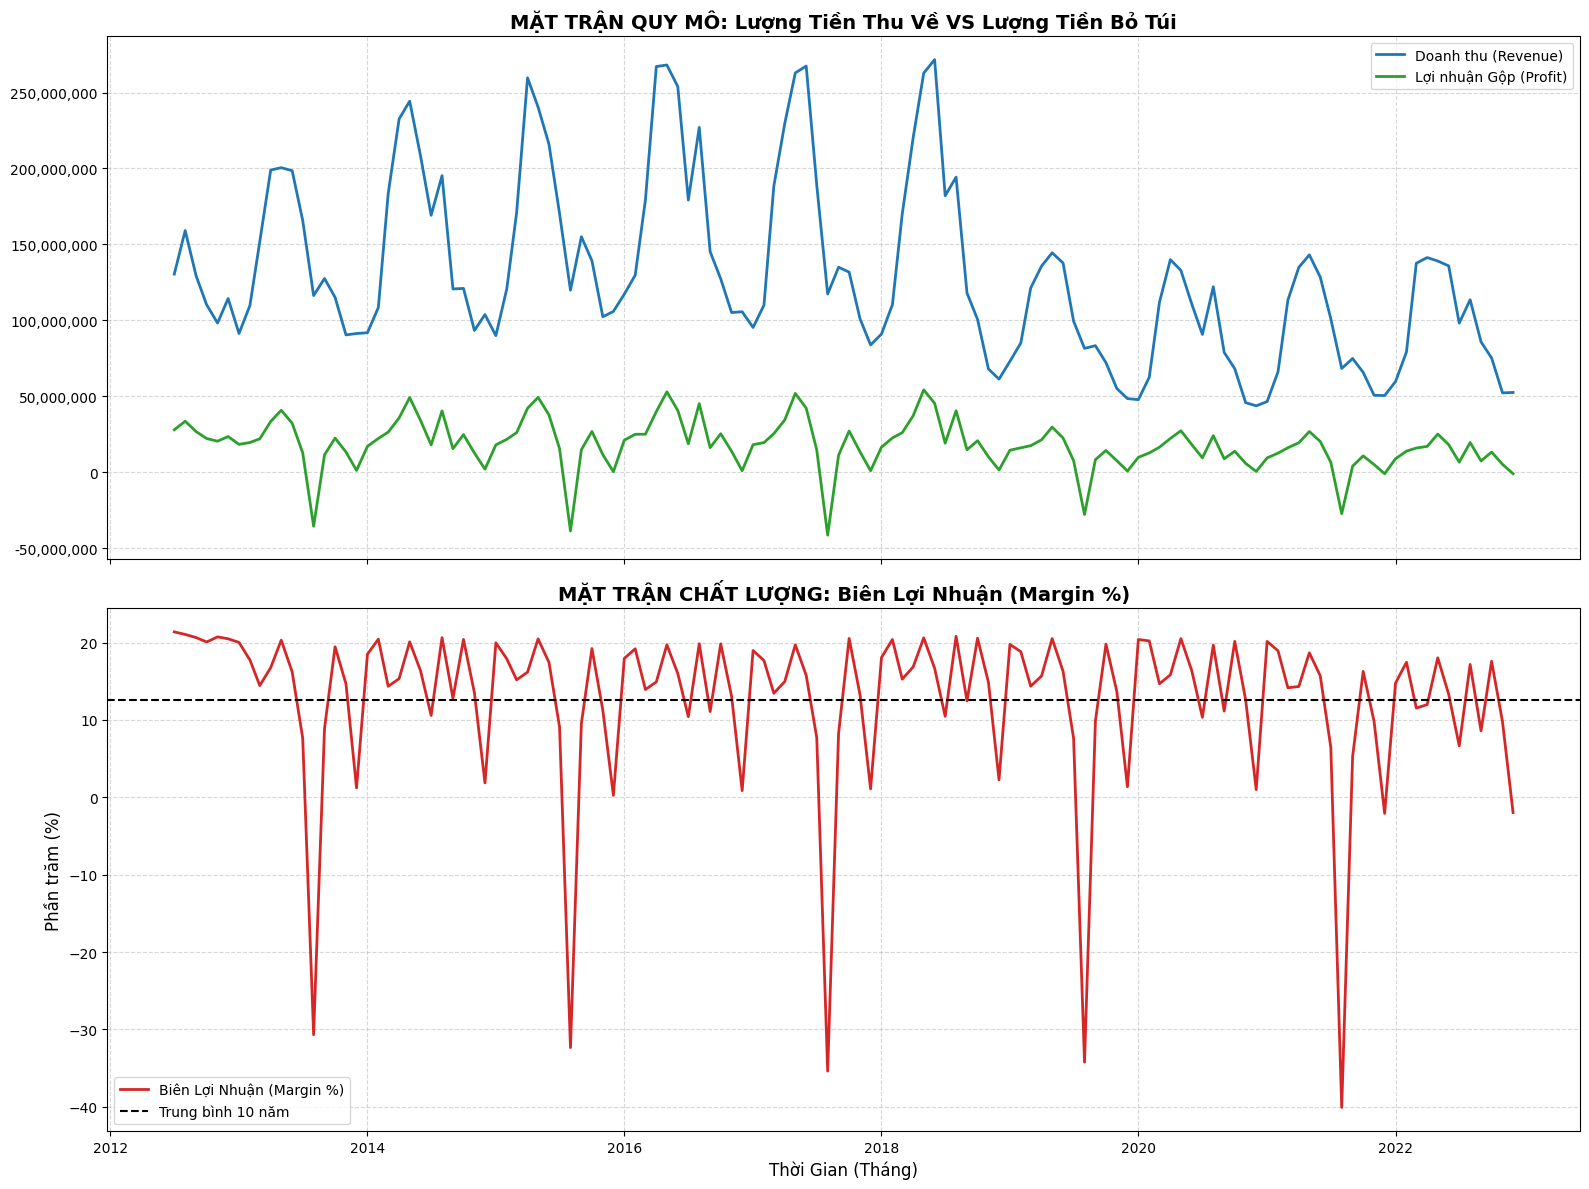

In [11]:
# 1. Dùng SQL tính Toán Doanh thu, Lợi nhuận và Margin
sql_margin = """
    SELECT 
        DATE_TRUNC('month', CAST(date AS DATE)) AS month_year, 
        SUM(revenue) AS total_revenue,
        SUM(revenue - cogs) AS total_profit,
        (SUM(revenue - cogs) / SUM(revenue)) * 100 AS margin_percentage
    FROM sales
    GROUP BY month_year
    ORDER BY month_year
"""
df_margin = con.execute(sql_margin).df()

# 2. Vẽ 2 biểu đồ xếp chồng: Lượng Tiền (Volume) vs Chất Tiền (Margin)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12), sharex=True)

# Biểu đồ trên: Doanh thu và Lợi nhuận tuyệt đối
ax1.plot(df_margin['month_year'], df_margin['total_revenue'], label='Doanh thu (Revenue)', color='#1f77b4', linewidth=2)
ax1.plot(df_margin['month_year'], df_margin['total_profit'], label='Lợi nhuận Gộp (Profit)', color='#2ca02c', linewidth=2)
ax1.set_title('MẶT TRẬN QUY MÔ: Lượng Tiền Thu Về VS Lượng Tiền Bỏ Túi', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

# Biểu đồ dưới: Biên Lợi Nhuận (%)
ax2.plot(df_margin['month_year'], df_margin['margin_percentage'], label='Biên Lợi Nhuận (Margin %)', color='#d62728', linewidth=2)
ax2.axhline(df_margin['margin_percentage'].mean(), color='black', linestyle='--', label='Trung bình 10 năm')
ax2.set_title('MẶT TRẬN CHẤT LƯỢNG: Biên Lợi Nhuận (Margin %)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Phần trăm (%)', fontsize=12)
ax2.set_xlabel('Thời Gian (Tháng)', fontsize=12)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. Tóm tắt Thực thi (Executive Summary)
- Dựa trên việc khai phá dữ liệu lịch sử bán hàng trong giai đoạn 2012 - 2022, nhóm phân tích phát hiện một rủi ro cấu trúc nghiêm trọng trong mô hình tăng trưởng của doanh nghiệp. Mặc dù công ty liên tục thiết lập các đỉnh mới về mặt doanh thu (Top-line) trong các giai đoạn cao điểm mùa vụ, nhưng chất lượng dòng tiền (Bottom-line) lại suy giảm trầm trọng. Doanh nghiệp đang mắc kẹt trong "Bẫy khuyến mãi" – đánh đổi trực tiếp sự sống còn của Biên lợi nhuận lấy Quy mô bán hàng.

2. Phát hiện Cốt lõi (Key Findings)
- Sự phân kỳ giữa Doanh thu và Lợi nhuận: Phân tích biểu đồ chuỗi thời gian cho thấy mối tương quan nghịch (inverse correlation) tuyệt đối giữa Doanh thu (Revenue) và Lợi nhuận gộp (Gross Profit). Tại các tháng có doanh thu chạm đỉnh (spikes), đường lợi nhuận không những không tăng mà còn xuyên thủng mức 0, chuyển sang trạng thái âm.

Biên lợi nhuận (Margin) sụp đổ: Trong điều kiện bình thường, Margin duy trì ở mức trung bình ổn định (khoảng 15%). Tuy nhiên, vào các chu kỳ bùng nổ doanh số, Margin lao dốc không phanh, chạm đáy ở mức âm 30% đến âm 40%.

3. Phân tích Nguyên nhân Gốc rễ (Root Cause Analysis)
- Thực trạng suy kiệt Biên lợi nhuận bắt nguồn trực tiếp từ Chiến lược lạm dụng giảm giá sâu (Deep Discounting Strategy):

- Để đạt được KPI (Chỉ tiêu) về Volume trong các chiến dịch Mega Sale hoặc dịp Lễ/Tết, bộ phận Kinh doanh đã áp dụng các chính sách hạ giá cực đoan nhằm kích cầu.

- Tổng chi phí khuyến mãi (Discount Amount) phát sinh trong các tháng này vượt quá ngưỡng an toàn tài chính, dẫn đến tình trạng bán hàng dưới giá vốn (Selling below COGS).

=> Kết luận: Động lực tăng trưởng doanh thu hiện tại không đến từ năng lực cốt lõi của sản phẩm hay tệp khách hàng trung thành, mà hoàn toàn bị phụ thuộc (nghiện) vào các gói trợ giá. Càng bán được nhiều hàng trong các dịp lễ, doanh nghiệp càng chịu khoản lỗ lớn.

4. Hàm ý Chiến lược & Định hướng Giải pháp (Strategic Implications & Solutions)
Việc tiếp tục mô hình "Mua doanh thu bằng Khuyến mãi" là không bền vững và mang tính sát thương cao đối với dòng tiền vận hành của công ty. Để giải quyết bài toán Trade-off (đánh đổi) này, nhóm đề xuất:

- Dừng phương pháp Định giá Cảm tính: Thay thế các quyết định giảm giá hàng loạt (mass-discounting) bằng phương pháp tiếp cận dựa trên dữ liệu (Data-driven).

- Ứng dụng Machine Learning (LightGBM): Xây dựng Hệ thống Dự báo và Tối ưu hóa Khuyến mãi. Hệ thống AI này sẽ có nhiệm vụ dò tìm "Điểm rơi tối ưu" (Sweet Spot): Tính toán mức tỷ lệ giảm giá vừa đủ để tối đa hóa số lượng đơn hàng (Volume) nhưng vẫn đảm bảo Biên lợi nhuận (Margin) luôn được giữ ở mức dương an toàn.

## "BẮT TẬN TAY" THỦ PHẠM KHUYẾN MÃI (Discount Analysis)

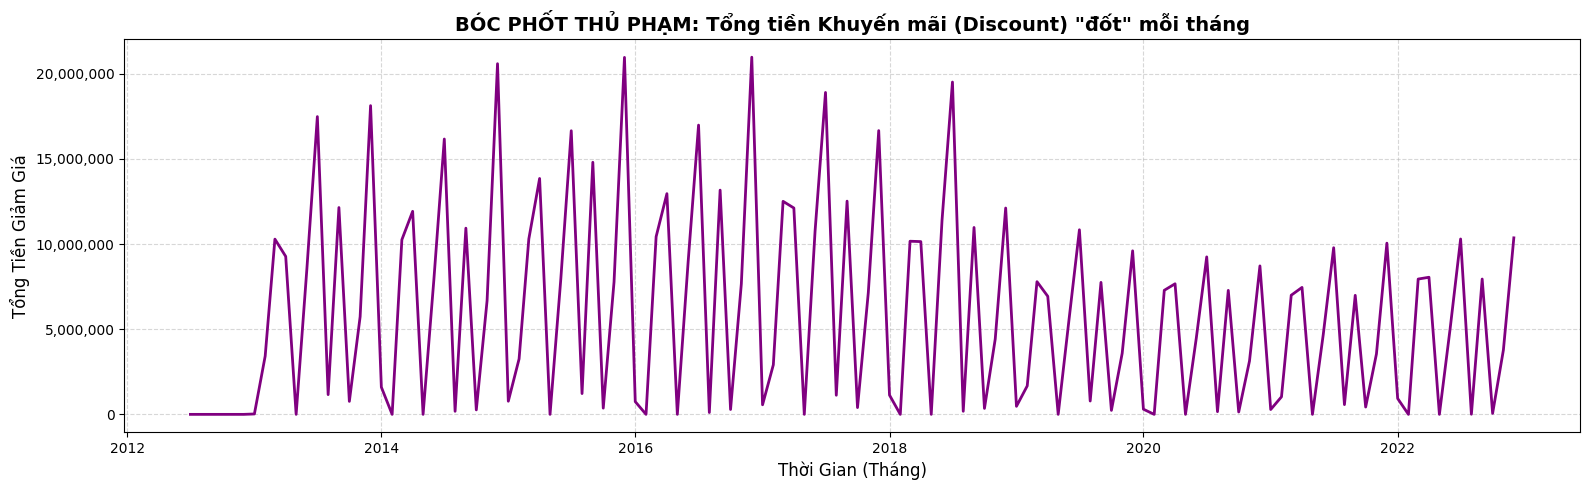

In [12]:
# Móc nối bảng orders (lấy ngày) và bảng order_items (lấy tiền giảm giá)
sql_discount = """
    SELECT 
        DATE_TRUNC('month', CAST(o.order_date AS DATE)) AS month_year, 
        SUM(oi.discount_amount) AS total_discount
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month_year
    ORDER BY month_year
"""

df_discount = con.execute(sql_discount).df()

# Vẽ biểu đồ "Bóc phốt"
plt.figure(figsize=(16, 5))
plt.plot(df_discount['month_year'], df_discount['total_discount'], color='purple', linewidth=2)

plt.title('BÓC PHỐT THỦ PHẠM: Tổng tiền Khuyến mãi (Discount) "đốt" mỗi tháng', fontsize=14, fontweight='bold')
plt.xlabel('Thời Gian (Tháng)', fontsize=12)
plt.ylabel('Tổng Tiền Giảm Giá', fontsize=12)

# Định dạng số cho dễ nhìn
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

1. Chu kỳ "Đốt tiền" Khắc nghiệt (Extreme Cyclical Cash Burn)
- Biểu đồ Tổng tiền Khuyến mãi cho thấy tính mùa vụ (seasonality) cực kỳ gắt gao trong các chiến lược kích cầu của doanh nghiệp. Các đỉnh nhọn (spikes) xuất hiện đều đặn hàng năm, minh chứng cho việc công ty liên tục triển khai các chiến dịch Mega Sale để chạy KPI doanh số vào các dịp cuối năm hoặc Lễ/Tết.

2. Phân kỳ Giai đoạn Lịch sử (Historical Phasing)
- Nhìn vào chuỗi thời gian 10 năm, chiến lược ngân sách khuyến mãi được chia thành 2 giai đoạn rõ rệt:

    - Giai đoạn Đỉnh điểm (2014 - 2019): Đây là thời kỳ doanh nghiệp "mua doanh thu" bằng mọi giá. Các đỉnh khuyến mãi liên tục xuyên thủng mốc 15 triệu đô, thậm chí chạm ngưỡng hơn 20 triệu đô/tháng. Khớp nối với phân tích trước đó, đây chính là tác nhân trực tiếp kéo Biên lợi nhuận gộp (Margin) chìm sâu xuống mức âm 30% - 40%.

    - Giai đoạn Bình thường mới (2020 - 2022): Ngân sách khuyến mãi có sự thu hẹp đáng kể, các đỉnh cao nhất chỉ còn dao động quanh mốc 10 triệu đô. Điều này lý giải tại sao Quy mô doanh thu (Volume) trong giai đoạn này bị thu hẹp chỉ còn một nửa so với thời kỳ hoàng kim. Khi "thuốc kích thích" giảm giá bị rút bớt, doanh số ngay lập tức lao dốc.

3. Kết luận Kinh doanh (Business Conclusion)
- Biểu đồ này là bằng chứng định lượng (quantitative evidence) xác đáng nhất cho thấy doanh nghiệp đang thiếu một chiến lược tối ưu giá. Việc lạm dụng trợ giá không tạo ra tệp khách hàng trung thành mà chỉ tạo ra "khách hàng săn sale".

- Định hướng hành động: Nhiệm vụ cấp thiết hiện tại là phải đưa Thuật toán Học máy (Machine Learning) vào quá trình ra quyết định. Thay vì giảm giá "cào bằng" và đâm thủng đáy lợi nhuận, hệ thống AI sẽ phải tìm ra ngưỡng Discount tối ưu để cân bằng giữa Quy mô (Volume) và Lợi nhuận (Margin).

In [ ]:
import os
import pandas as pd
from src.connection import get_connection

con = get_connection()

# 1. Tự động tạo thư mục 'processed' nếu chưa có để tránh lỗi FileNotFoundError
os.makedirs('../data/processed', exist_ok=True)

# 2. Truy vấn lại df_ml (Sức khỏe dòng tiền & Khuyến mãi)
sql_ml_features = """
    WITH MonthlyData AS (
        SELECT 
            DATE_TRUNC('month', CAST(s.date AS DATE)) AS month_year,
            SUM(s.revenue) AS current_revenue,
            SUM(s.revenue - s.cogs) AS current_profit,
            COALESCE(SUM(oi.discount_amount), 0) AS total_discount
        FROM sales s
        LEFT JOIN orders o ON s.date = o.order_date
        LEFT JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY month_year
    )
    SELECT 
        month_year,
        current_revenue,
        current_profit,
        total_discount,
        (total_discount / NULLIF(current_revenue, 0)) * 100 AS discount_intensity_pct,
        (current_profit / NULLIF(current_revenue, 0)) * 100 AS margin_pct
    FROM MonthlyData
"""
df_ml = con.execute(sql_ml_features).df().dropna()

# 3. Truy vấn lại df_prod (Top 10 Sản phẩm Pareto)
sql_product_performance = """
    SELECT 
        p.product_id,
        SUM(oi.unit_price * oi.quantity) AS gross_revenue,
        SUM(oi.discount_amount) AS total_given_discount,
        (SUM(oi.discount_amount) / SUM(oi.unit_price * oi.quantity)) * 100 AS discount_rate
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_id
    ORDER BY gross_revenue DESC
    LIMIT 10
"""
df_prod = con.execute(sql_product_performance).df()

# 4. Xuất file CSV
df_ml.to_csv('../data/processed/data_for_powerbi.csv', index=False)
df_prod.to_csv('../data/processed/top_products.csv', index=False)

print("Đã xuất thành công 2 file CSV vào thư mục 'data/processed/'.")

✅ TUYỆT VỜI! Đã xuất thành công 2 file CSV vào thư mục 'data/processed/'.
Bạn có thể mở Power BI lên và Get Data từ 2 file này được rồi nhé!
